In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('email_spam_detection.csv')
data

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
0,1,,Meeting,NaN,99,-1,7,0,0
1,2,user1@outlook.com,Security Alert,87.0,2,3,8,0,0
2,3,user2@yahoo.com,Win Prize,69.0,0,3,8,0,0
3,4,user3@gmail.com,Invoice,61.0,0,3,8,0,0
4,5,user4@company.com,Meeting,99.0,2,3,5,0,0
...,...,...,...,...,...,...,...,...,...
6995,6996,user6995@gmail.com,Greetings,93.0,1,2,6,1,0
6996,6997,user6996@yahoo.com,Offer,107.0,0,0,7,0,0
6997,6998,user6997@gmail.com,Account Verification,222.0,7,14,17,0,1
6998,6999,user6998@outlook.com,Win Prize,164.0,6,16,8,1,1


In [3]:
data.shape

(7000, 9)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Email_ID           7000 non-null   int64  
 1   Sender_Email       6999 non-null   str    
 2   Subject            7000 non-null   str    
 3   Email_Length       6959 non-null   float64
 4   Num_Links          7000 non-null   int64  
 5   Num_Special_Chars  7000 non-null   int64  
 6   Capital_Words      7000 non-null   int64  
 7   Has_Attachment     7000 non-null   int64  
 8   Spam               7000 non-null   int64  
dtypes: float64(1), int64(6), str(2)
memory usage: 694.4 KB


In [5]:
data.describe()

,Email_ID,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
count,7000.000000,6959.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,3500.500000,110.567898,2.454571,6.636429,12.199714,0.260714,0.305143
std,2020.870275,52.353566,5.319235,6.123388,15.169749,0.439056,0.460501
min,1.000000,20.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,1750.750000,70.000000,0.000000,2.000000,3.000000,0.000000,0.000000
50%,3500.500000,95.000000,1.000000,4.000000,6.000000,0.000000,0.000000
75%,5250.250000,158.000000,3.000000,11.000000,10.250000,1.000000,1.000000
max,7000.000000,265.000000,99.000000,28.000000,59.000000,1.000000,1.000000


In [6]:
# missing values
data.isnull().sum()

Email_ID              0
Sender_Email          1
Subject               0
Email_Length         41
Num_Links             0
Num_Special_Chars     0
Capital_Words         0
Has_Attachment        0
Spam                  0
dtype: int64

In [7]:
data['Sender_Email'].unique()

<ArrowStringArray>
[                   ' ',    'user1@outlook.com',      'user2@yahoo.com',
      'user3@gmail.com',    'user4@company.com',      'user5@gmail.com',
      'user6@yahoo.com',      'user7@gmail.com',    'user8@company.com',
    'user9@company.com',
 ...
   'user6990@gmail.com', 'user6991@outlook.com', 'user6992@outlook.com',
   'user6993@gmail.com', 'user6994@outlook.com',   'user6995@gmail.com',
   'user6996@yahoo.com',   'user6997@gmail.com', 'user6998@outlook.com',
 'user6999@company.com']
Length: 6974, dtype: str

In [8]:
data[data['Sender_Email'].isna()]

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
257,258,NaN,Meeting,180.0,1,22,42,0,1


In [9]:
data["Sender_Email"] = (
    data["Sender_Email"]
    .replace(r"^\s*$", "unknown", regex=True)
    .fillna("unknown")
)

In [10]:
data.isnull().sum()

Email_ID              0
Sender_Email          0
Subject               0
Email_Length         41
Num_Links             0
Num_Special_Chars     0
Capital_Words         0
Has_Attachment        0
Spam                  0
dtype: int64

In [11]:
data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
6995    False
6996    False
6997    False
6998    False
6999    False
Length: 7000, dtype: bool

In [12]:
data.drop_duplicates()

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
0,1,unknown,Meeting,NaN,99,-1,7,0,0
1,2,user1@outlook.com,Security Alert,87.0,2,3,8,0,0
2,3,user2@yahoo.com,Win Prize,69.0,0,3,8,0,0
3,4,user3@gmail.com,Invoice,61.0,0,3,8,0,0
4,5,user4@company.com,Meeting,99.0,2,3,5,0,0
...,...,...,...,...,...,...,...,...,...
6995,6996,user6995@gmail.com,Greetings,93.0,1,2,6,1,0
6996,6997,user6996@yahoo.com,Offer,107.0,0,0,7,0,0
6997,6998,user6997@gmail.com,Account Verification,222.0,7,14,17,0,1
6998,6999,user6998@outlook.com,Win Prize,164.0,6,16,8,1,1


In [13]:
data.dtypes

Email_ID               int64
Sender_Email             str
Subject                  str
Email_Length         float64
Num_Links              int64
Num_Special_Chars      int64
Capital_Words          int64
Has_Attachment         int64
Spam                   int64
dtype: object

In [14]:
data[data['Email_Length'].isna() == True]

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
0,1,unknown,Meeting,NaN,99,-1,7,0,0
173,174,user173@outlook.com,Project Update,NaN,6,17,20,1,1
346,347,user346@outlook.com,Greetings,NaN,3,6,9,0,0
519,520,user519@gmail.com,Greetings,NaN,3,15,25,1,1
692,693,user692@gmail.com,Meeting,NaN,2,2,6,0,0
865,866,user865@gmail.com,Invoice,NaN,1,7,7,0,0
1038,1039,user1038@company.com,Win Prize,NaN,0,2,4,1,0
1211,1212,user1211@company.com,Account Verification,NaN,2,4,9,0,0
1384,1385,user1384@outlook.com,Project Update,NaN,9,17,11,1,1
1557,1558,user1557@outlook.com,Account Verification,NaN,3,3,9,0,0


In [15]:
data['Email_Length'] = data['Email_Length'].fillna(0)

In [16]:
data[data['Email_Length'].isna() == True]

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam


In [17]:
data['Num_Special_Chars'].unique()

array([-1,  3,  1, 14, 17,  9,  4, 12, 16,  8, 15, 19, 22, 13, 11,  2,  5,
        7,  0, 18,  6, 21, 10, 20, 27, 24, 23, 25, 26, 28])

In [18]:
data['Num_Special_Chars'] = data['Num_Special_Chars'].replace(-1, 0)

In [19]:
data['Num_Special_Chars'].unique()

array([ 0,  3,  1, 14, 17,  9,  4, 12, 16,  8, 15, 19, 22, 13, 11,  2,  5,
        7, 18,  6, 21, 10, 20, 27, 24, 23, 25, 26, 28])

<Axes: ylabel='Num_Links'>

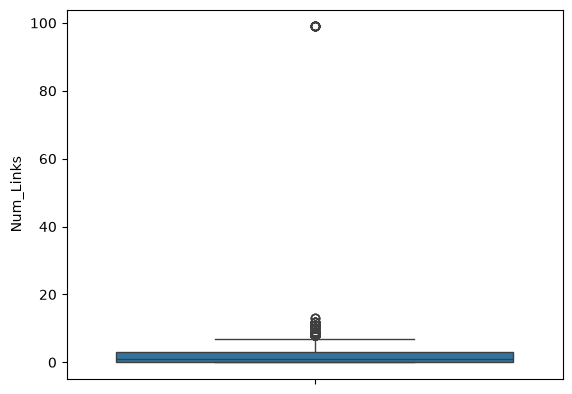

In [20]:
sns.boxplot(data['Num_Links'])

In [21]:
sorted(data['Num_Links'], reverse=True)

[99,
 99,
 99,
 99,
 99,
 99,
 99,
 99,
 99,
 99,
 99,
 99,
 99,
 99,
 99,
 99,
 99,
 13,
 13,
 13,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 

In [22]:
data = data[~(data['Num_Links'] == 99 )] # outliers removal

In [23]:
sorted(data['Num_Links'], reverse=True)

[13,
 13,
 13,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8

In [24]:
data.value_counts()

Email_ID  Sender_Email          Subject               Email_Length  Num_Links  Num_Special_Chars  Capital_Words  Has_Attachment  Spam
2         user1@outlook.com     Security Alert        87.0          2          3                  8              0               0       1
3         user2@yahoo.com       Win Prize             69.0          0          3                  8              0               0       1
4         user3@gmail.com       Invoice               61.0          0          3                  8              0               0       1
5         user4@company.com     Meeting               99.0          2          3                  5              0               0       1
6         user5@gmail.com       Invoice               52.0          5          1                  8              1               0       1
                                                                                                                                        ..
6996      user6995@gmail.com    

In [25]:
data.columns

Index(['Email_ID', 'Sender_Email', 'Subject', 'Email_Length', 'Num_Links',
       'Num_Special_Chars', 'Capital_Words', 'Has_Attachment', 'Spam'],
      dtype='str')

In [26]:
data['Subject'].unique()

<ArrowStringArray>
[      'Security Alert',            'Win Prize',              'Invoice',
              'Meeting',                'Offer',       'Project Update',
            'Greetings', 'Account Verification']
Length: 8, dtype: str

In [27]:
data['Num_Special_Chars'].unique()

array([ 3,  1, 14, 17,  9,  4, 12, 16,  8, 15, 19, 22, 13, 11,  2,  5,  7,
        0, 18,  6, 21, 10, 20, 27, 24, 23, 25, 26, 28])

In [28]:
data['Num_Links'].unique()

array([ 2,  0,  5,  8,  7,  1,  3,  4, 10,  6,  9, 11, 12, 13])

In [29]:
data['Capital_Words'].unique()

array([ 8,  5, 10, 43, 38,  2, 51,  7,  0,  6, 24,  3, 25, 52, 36, 11,  1,
        4, 40, 15, 35, 31, 42, 23,  9, 12, 17, 18, 29, 16, 48, 59, 58, 21,
       19, 56, 22, 41, 32, 55, 37, 13, 50, 20, 53, 27, 49, 45, 34, 30, 54,
       57, 28, 39, 14, 26, 44, 33, 46, 47])

In [30]:
data['Has_Attachment'].unique()

array([0, 1])

In [31]:
# Data cleaned 
data

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
1,2,user1@outlook.com,Security Alert,87.0,2,3,8,0,0
2,3,user2@yahoo.com,Win Prize,69.0,0,3,8,0,0
3,4,user3@gmail.com,Invoice,61.0,0,3,8,0,0
4,5,user4@company.com,Meeting,99.0,2,3,5,0,0
5,6,user5@gmail.com,Invoice,52.0,5,1,8,1,0
...,...,...,...,...,...,...,...,...,...
6995,6996,user6995@gmail.com,Greetings,93.0,1,2,6,1,0
6996,6997,user6996@yahoo.com,Offer,107.0,0,0,7,0,0
6997,6998,user6997@gmail.com,Account Verification,222.0,7,14,17,0,1
6998,6999,user6998@outlook.com,Win Prize,164.0,6,16,8,1,1


# Model Training

In [54]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# Text feature
text = data["Subject"].fillna("")

# Numeric features
numeric = data[[
    "Email_Length",
    "Num_Links",
    "Num_Special_Chars",
    "Capital_Words",
    "Has_Attachment"
]]

# Convert subject to TF-IDF
vectorizer = TfidfVectorizer(max_features=3000)
X_text = vectorizer.fit_transform(text)

# Combine text and numeric features
X = hstack([X_text, numeric.values])

# Target variable
y = data["Spam"]

joblib.dump(vectorizer, 'vectorizer.joblib')

['vectorizer.joblib']

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

model1 = LogisticRegression()
model2 = DecisionTreeClassifier()
model3 = KNeighborsClassifier(n_neighbors=5)

In [35]:
# finding best k value
from sklearn.metrics import accuracy_score
scores = []

for i in range (1, 11):

    knn = KNeighborsClassifier(n_neighbors=i)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    scores.append(accuracy_score(y_test, y_pred))

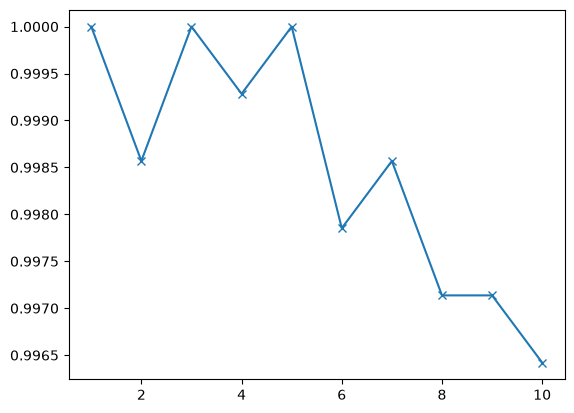

In [36]:
plt.plot(range(1, 11), scores, marker='x')

In [37]:
scores

[1.0,
 0.9985683607730852,
 1.0,
 0.9992841803865425,
 1.0,
 0.9978525411596277,
 0.9985683607730852,
 0.9971367215461704,
 0.9971367215461704,
 0.9964209019327129]

In [38]:
# 5 is ideal for values on k

In [39]:
model1.fit(X_train, y_train)
model2.fit(X_train, y_train)
model3.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [40]:
y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)
y_pred3 = model3.predict(X_test)

In [41]:
# acuracy
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy of Logistic Regression : ", accuracy_score(y_test, y_pred1))
print("Accuracy of Decision Tree : ", accuracy_score(y_test, y_pred2))
print("Accuracy of KNN : ", accuracy_score(y_test, y_pred3))

Accuracy of Logistic Regression :  0.9992841803865425
Accuracy of Decision Tree :  0.9992841803865425
Accuracy of KNN :  1.0


In [42]:
print("Logistic Regression Confusion Matrix\n")
pd.DataFrame(confusion_matrix(y_test, y_pred1))

Logistic Regression Confusion Matrix



,0,1
0,950,0
1,1,446


In [43]:
print("Decision Tree Confusion Matrix\n")
pd.DataFrame(confusion_matrix(y_test, y_pred2))

Decision Tree Confusion Matrix



,0,1
0,949,1
1,0,447


In [44]:
print("KNN Confusion Matrix\n")
pd.DataFrame(confusion_matrix(y_test, y_pred3))

KNN Confusion Matrix



,0,1
0,950,0
1,0,447


In [45]:
# saving the model
knn = KNeighborsClassifier(n_neighbors=5)

In [46]:
knn_final = knn.fit(X, y)

In [48]:
import joblib

joblib.dump(knn_final, 'knn_model.joblib')

['knn_model.joblib']

In [52]:
data.head()

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
1,2,user1@outlook.com,Security Alert,87.0,2,3,8,0,0
2,3,user2@yahoo.com,Win Prize,69.0,0,3,8,0,0
3,4,user3@gmail.com,Invoice,61.0,0,3,8,0,0
4,5,user4@company.com,Meeting,99.0,2,3,5,0,0
5,6,user5@gmail.com,Invoice,52.0,5,1,8,1,0


In [53]:
data.describe()

,Email_ID,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
count,6983.000000,6983.000000,6983.000000,6983.000000,6983.000000,6983.000000,6983.000000
mean,3500.859086,109.908922,2.219533,6.636116,12.204353,0.260633,0.304883
std,2020.779092,52.837569,2.369131,6.117680,15.176189,0.439011,0.460391
min,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1751.500000,70.000000,0.000000,2.000000,3.000000,0.000000,0.000000
50%,3501.000000,94.000000,1.000000,4.000000,6.000000,0.000000,0.000000
75%,5250.500000,157.000000,3.000000,11.000000,10.000000,1.000000,1.000000
max,7000.000000,265.000000,13.000000,28.000000,59.000000,1.000000,1.000000
